In [ ]:
!pip install ultralytics -q
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.5 MB/s eta 0:00:00


In [ ]:
import os
import shutil
import random
random.seed(42)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!rm -rf /content/dataset
!cp -r "/content/drive/MyDrive/archive/content/unified_dataset" /content/dataset

In [ ]:
source_dir = "/content/dataset"
output_dir = "/content/waste_dataset"

train_dir = os.path.join(output_dir, "train")
val_dir = os.path.join(output_dir, "val")

# reset old data
!rm -rf /content/waste_dataset

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

In [ ]:
random.seed(42)

# Define the 'classes' variable by listing subdirectories in source_dir
classes = os.listdir(source_dir)

for cls in classes:

    cls_path = os.path.join(source_dir, cls)

    images = os.listdir(cls_path)
    random.shuffle(images)

    split = int(0.8 * len(images))

    train_imgs = images[:split]
    val_imgs = images[split:]

    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)

    for img in train_imgs:
        try:
            shutil.copy(
                os.path.join(cls_path, img),
                os.path.join(train_dir, cls, img)
            )
        except:
            pass

    for img in val_imgs:
        try:
            shutil.copy(
                os.path.join(cls_path, img),
                os.path.join(val_dir, cls, img)
            )
        except:
            pass

print("Dataset split completed!")

Dataset split completed!


In [ ]:
print("Train classes:")
print(os.listdir(train_dir))

print("Val classes:")
print(os.listdir(val_dir))

Train classes:
['paper_cardboard', 'textiles', 'trash', 'plastic', 'glass', 'battery', 'metal', 'organic_waste']
Val classes:
['paper_cardboard', 'textiles', 'trash', 'plastic', 'glass', 'battery', 'metal', 'organic_waste']


In [ ]:
from ultralytics import YOLO
model = YOLO("yolov8n-cls.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [12]:
results = model.train(
    data=output_dir,
    epochs=20,
    imgsz=224,
    batch=16,
    device="cpu"
)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/waste_dataset, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective

In [13]:
metrics = model.val()

print("Top-1 Accuracy:", metrics.top1)
print("Top-5 Accuracy:", metrics.top5)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
YOLOv8n-cls summary (fused): 30 layers, 1,445,128 parameters, 0 gradients, 3.3 GFLOPs
ERROR ❌ train: /content/waste_dataset/train... found 13605 images in 3 classes (requires 8 classes, not 3)
ERROR ❌ val: /content/waste_dataset/val... found 3403 images in 3 classes (requires 8 classes, not 3)
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 539.4±252.3 MB/s, size: 15.7 KB)
val: Scanning /content/waste_dataset/val... 3403 images, 0 corrupt: 100% ━━━━━━━━━━━━ 3403/3403 549.0Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 213/213 6.0it/s 35.5s
                   all      0.994          1
Speed: 0.0ms preprocess, 9.0ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val
Top-1 Accuracy: 0.9941228032112122
Top-5 Accuracy: 1.0


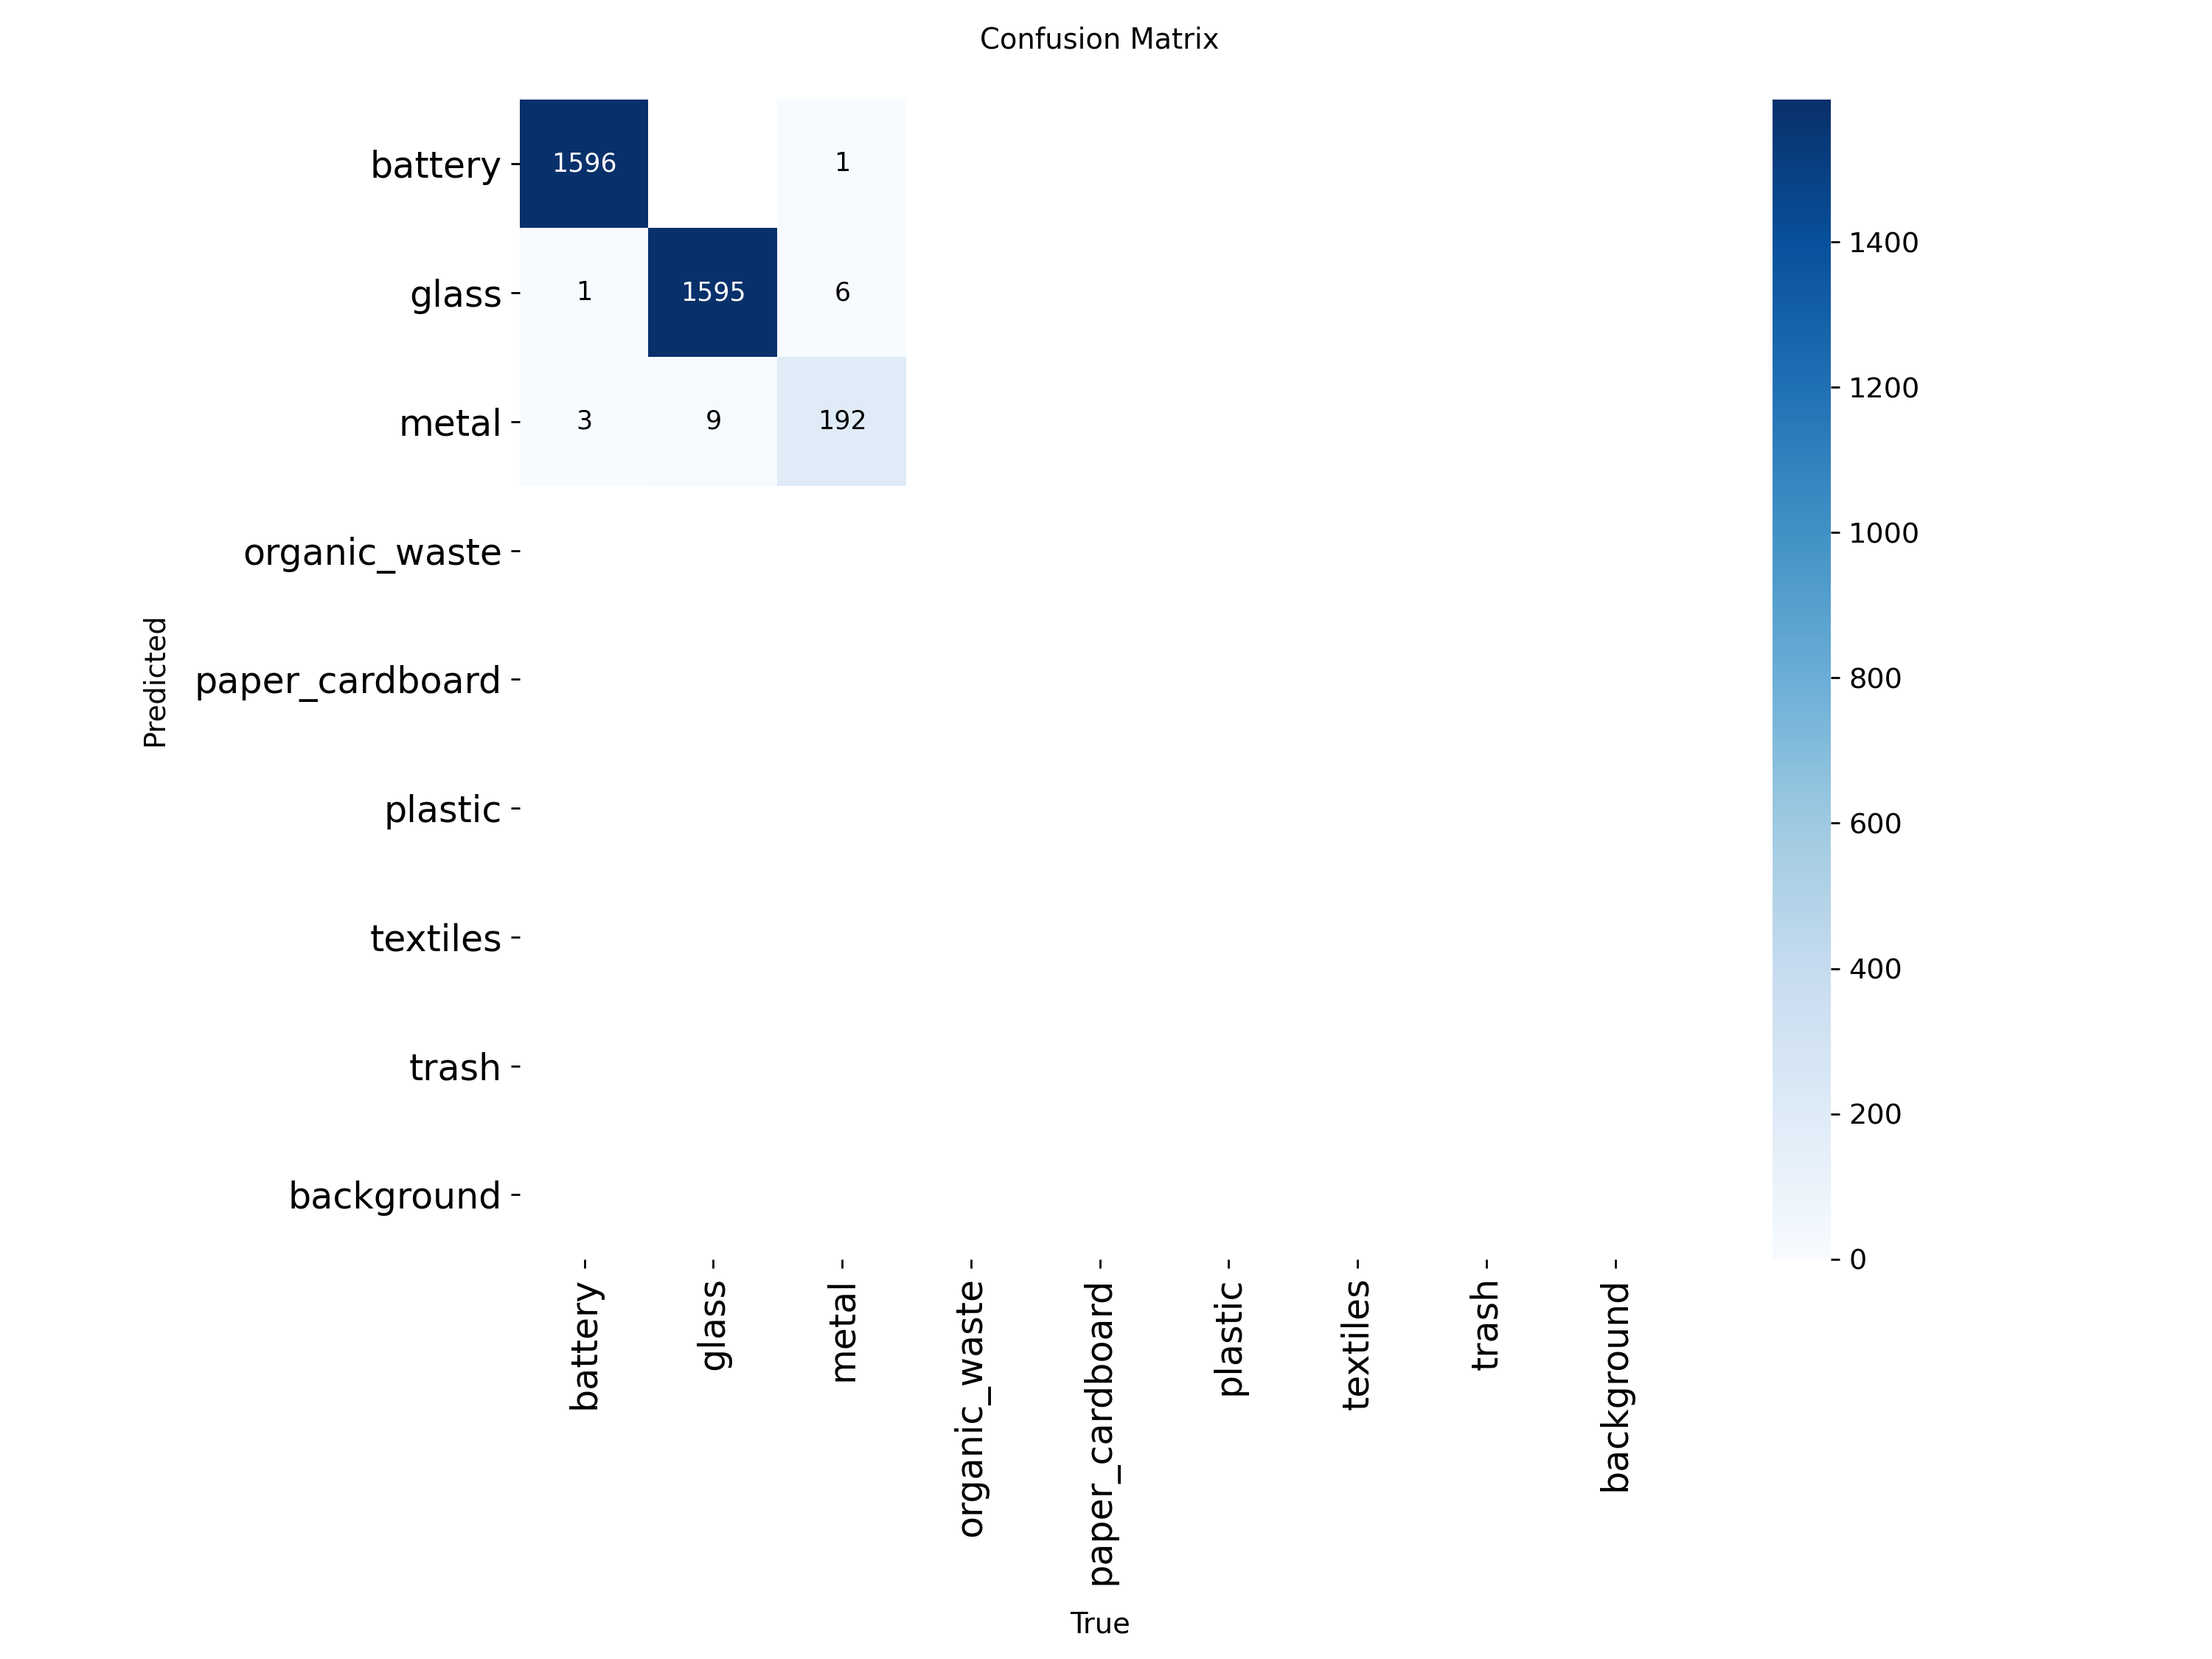

In [17]:
from IPython.display import Image

Image("/content/runs/classify/train-2/confusion_matrix.png")

In [20]:
results = model.predict("test.png", save=True)

for r in results:
    probs = r.probs
    if probs is not None:
        print("Class:", r.names[probs.top1])
        print("Confidence:", probs.top1conf.item())


image 1/1 /content/test.png: 224x224 glass 1.00, metal 0.00, battery 0.00, organic_waste 0.00, paper_cardboard 0.00, 21.8ms
Speed: 3.3ms preprocess, 21.8ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
Results saved to /content/runs/classify/predict
Class: glass
Confidence: 0.9999953508377075
